# 📘 Multi-Factor Models

---

## 🎯 Learning Objectives

By the end of this notebook, you will be able to:

1. **Understand why investors move beyond CAPM** — Articulate the limitations of a single-market factor
2. **Estimate multi-factor models** — Regress asset/fund returns on factor portfolios; interpret loadings, alphas, and $R^2$
3. **Evaluate fund performance** — Distinguish genuine alpha from factor exposure using factor regressions
4. **Decompose portfolio risk** — Use both top-down and bottom-up approaches to separate systematic from idiosyncratic components
5. **Estimate factor premia** — Run Fama–MacBeth cross-sectional regressions and interpret characteristic-based risk prices
6. **Construct characteristic-adjusted returns** — Separate skill from style for any portfolio

## 📋 Table of Contents

1. [Why Multi-Factor Models?](#why-multi-factor)
2. [The Time-Series Approach](#time-series)
3. [Performance Attribution: Cathie Wood](#cathie-wood)
4. [Warren Buffett: Does He Beat the Market?](#warren-buffett)
5. [Bottom-Up vs Top-Down Decomposition](#bottom-up-top-down)
6. [The Cross-Sectional Approach](#cross-sectional)
7. [Exercises](#exercises)
8. [Key Takeaways](#key-takeaways)

---

## 🛠️ Setup

In [1]:
#@title 🛠️ Setup: Run this cell first (click to expand)

#!pip install wrds

In [2]:
import wrds

In [3]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas_datareader.data as web

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 12

import warnings
warnings.filterwarnings('ignore')

def get_factors(factors='CAPM', freq='daily'):
    if freq == 'monthly':
        freq_label = ''
    else:
        freq_label = '_' + freq

    if factors == 'CAPM':
        fama_french = web.DataReader("F-F_Research_Data_Factors" + freq_label, "famafrench", start="1921-01-01")
        df_factor = fama_french[0][['RF', 'Mkt-RF']]
    elif factors == 'FF3':
        fama_french = web.DataReader("F-F_Research_Data_Factors" + freq_label, "famafrench", start="1921-01-01")
        df_factor = fama_french[0][['RF', 'Mkt-RF', 'SMB', 'HML']]
    elif factors == 'FF5':
        fama_french = web.DataReader("F-F_Research_Data_Factors" + freq_label, "famafrench", start="1921-01-01")
        df_factor = fama_french[0][['RF', 'Mkt-RF', 'SMB', 'HML']]
        fama_french2 = web.DataReader("F-F_Research_Data_5_Factors_2x3" + freq_label, "famafrench", start="1921-01-01")
        df_factor = df_factor.merge(fama_french2[0][['RMW', 'CMA']], on='Date', how='outer')
    else:
        fama_french = web.DataReader("F-F_Research_Data_Factors" + freq_label, "famafrench", start="1921-01-01")
        df_factor = fama_french[0][['RF', 'Mkt-RF', 'SMB', 'HML']]
        fama_french2 = web.DataReader("F-F_Research_Data_5_Factors_2x3" + freq_label, "famafrench", start="1921-01-01")
        df_factor = df_factor.merge(fama_french2[0][['RMW', 'CMA']], on='Date', how='outer')
        fama_french3 = web.DataReader("F-F_Momentum_Factor" + freq_label, "famafrench", start="1921-01-01")
        df_factor = df_factor.merge(fama_french3[0], on='Date')
        df_factor.columns = ['RF', 'Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'MOM']

    if freq == 'monthly':
        df_factor.index = pd.to_datetime(df_factor.index.to_timestamp())
    else:
        df_factor.index = pd.to_datetime(df_factor.index)

    return df_factor / 100

def get_daily_wrds_multiple_ticker(tickers, conn):
    permnos = conn.get_table(library='crsp', table='stocknames',
                             columns=['permno', 'ticker', 'namedt', 'nameenddt'])
    permnos['nameenddt'] = pd.to_datetime(permnos['nameenddt'])
    permnos = permnos[(permnos['ticker'].isin(tickers)) &
                      (permnos['nameenddt'] == permnos['nameenddt'].max())]
    permno_list = permnos['permno'].unique().tolist()
    print(f"Found PERMNOs: {permno_list}")

    query = f"""
        SELECT permno, date, ret, retx, prc
        FROM crsp.dsf
        WHERE permno IN ({','.join(map(str, permno_list))})
        ORDER BY date
    """
    daily_returns = conn.raw_sql(query, date_cols=['date'])
    daily_returns = daily_returns.merge(permnos[['permno', 'ticker']], on='permno', how='left')
    daily_returns = daily_returns.pivot(index='date', columns='ticker', values='ret')
    daily_returns = daily_returns[tickers]
    return daily_returns

def get_permnos(tickers, conn):
    permnos = conn.get_table(library='crsp', table='stocknames',
                             columns=['permno', 'ticker', 'namedt', 'nameenddt'])
    permnos['nameenddt'] = pd.to_datetime(permnos['nameenddt'])
    permnos = permnos[permnos['ticker'].isin(tickers)]
    return permnos

---

## Why Multi-Factor Models? <a id="why-multi-factor"></a>

So far we have focused on the market as our single factor. In practice, it is standard to use models with **many factors**. Additional factors:

- **Soak up risk** — making measures of alpha more precise
- **Difference out** other sources of expected excess returns that are easy to access
- **Allow for better risk management** across multiple dimensions

We extend the single-factor model by adding more regressors. With $m$ factors:

$$r_t^i = b_{i,1} f_t^1 + b_{i,2} f_t^2 + \cdots + b_{i,m} f_t^m + \epsilon_{i,t}$$

In matrix notation, stacking all $n$ assets:

$$R_t = B \cdot F_t + U_t$$

where $B$ is $n \times m$ (each row = one asset's exposures), $F_t$ is $m \times 1$ (factor returns), and $U_t$ is the vector of idiosyncratic residuals.

### "Endogenous" Benchmarking

Large allocators often set benchmarks for managers. The most common is the S&P 500 (≈ market return), but you can also construct **endogenous benchmarks**:

$$r^b_t = \sum_j \beta_j F_{j,t}$$

Use the multi-factor combination that best replicates the portfolio as the benchmark. This is typically done implicitly: you allocate to funds based on their **alpha** (hard to get) rather than their beta exposure (cheap to replicate).

> **💡 Key Insight:**
>
> Alpha is scarce; beta is plentiful. You should pay different prices for each.
> The gains from beta are in *implementation* (low cost); the gains from alpha are in *selection* (finding skill).

---

## Estimating Multi-Factor Models: The Time-Series Approach <a id="time-series"></a>

We start with known factors and estimate betas using time-series regressions. This works especially well when factors are **excess returns** themselves.

For each asset, regress its excess returns on the factor excess returns:

$$r_t^{e,i} = \alpha_i + \beta_{i,1} f_t^1 + \cdots + \beta_{i,m} f_t^m + \epsilon_{i,t}$$

### Application: What Do Momentum ETFs Actually Deliver?

We'll take the largest ETFs claiming to implement momentum and see what factor exposures they actually have.

In [4]:
tickers = ["MTUM", "SPMO", "XMMO", "IMTM", "XSMO", "PDP", "JMOM", "DWAS", "VFMO", "XSVM", "QMOM"]
conn = wrds.Connection()

# Get daily returns and factor data
df_ETF = get_daily_wrds_multiple_ticker(tickers, conn)
df_factor = get_factors('FF6', 'daily')

# Align and compute excess returns
df_ETF, df_factor = df_ETF.align(df_factor, join='inner', axis=0)
df_ETF = df_ETF.subtract(df_factor['RF'], axis=0)

Loading library list...
Done
Found PERMNOs: [13512, 13851, 15161, 15725, 17085, 17392, 17622, 90621, 90622, 90623, 91876]


In [5]:
# Example: full regression for QMOM
X = sm.add_constant(df_factor.drop(columns=['RF']))
y = df_ETF["QMOM"].dropna()
X = X.loc[y.index]
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   QMOM   R-squared:                       0.762
Model:                            OLS   Adj. R-squared:                  0.762
Method:                 Least Squares   F-statistic:                     1217.
Date:                Mon, 13 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:15:29   Log-Likelihood:                 7764.5
No. Observations:                2284   AIC:                        -1.552e+04
Df Residuals:                    2277   BIC:                        -1.547e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.253e-05      0.000      0.133      0.8

In [6]:
# Run the regression for all momentum ETFs
Results = pd.DataFrame([], index=tickers, columns=X.columns)
for ticker in tickers:
    y = df_ETF[ticker]
    X = sm.add_constant(df_factor.drop(columns=['RF']))
    X = X[y.isna() == False]
    y = y[y.isna() == False]
    model = sm.OLS(y, X).fit()
    Results.loc[ticker, :] = model.params
    Results.at[ticker, 't_alpha'] = model.tvalues['const']
    Results.at[ticker, 'ivol'] = model.resid.std() * 252**0.5
    Results.at[ticker, 'Sample size'] = y.shape[0] / 252

Results['const'] = Results['const'].astype(float) * 252
Results.rename(columns={'const': 'alpha'}, inplace=True)
Results = Results[['alpha', 't_alpha', 'Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'MOM', 'ivol', 'Sample size']]
Results

,alpha,t_alpha,Mkt-RF,SMB,HML,RMW,CMA,MOM,ivol,Sample size
MTUM,-0.007184,-0.441952,1.024871,-0.105213,-0.057124,-0.127846,-0.027354,0.325909,0.055400,11.690476
SPMO,0.018246,0.776076,1.013657,-0.158928,-0.049394,-0.02647,0.076656,0.25509,0.071106,9.210317
XMMO,0.009431,0.496884,1.040259,0.337397,0.041132,0.030845,-0.105733,0.199555,0.084279,19.805556
IMTM,-0.033974,-1.061349,0.802455,-0.013844,0.057041,-0.133071,0.12565,0.118228,0.100624,9.944444
XSMO,-0.012768,-0.639363,0.984281,0.860455,0.191119,0.100718,-0.09243,0.165786,0.088671,19.805556
PDP,-0.015862,-1.055797,1.054885,0.142881,-0.00835,-0.083504,-0.184164,0.252145,0.063254,17.817460
JMOM,0.004130,0.203645,0.963249,0.012772,-0.06464,-0.07863,-0.066677,0.105358,0.053914,7.123016
DWAS,-0.010285,-0.495609,1.088441,1.075939,0.23163,-0.226312,-0.078938,0.400114,0.072943,12.428571
VFMO,0.011316,0.563876,1.03016,0.449136,0.185386,-0.221027,-0.061281,0.396359,0.052364,6.861111
XSVM,-0.004102,-0.220702,0.932729,0.983862,0.528043,0.329306,0.194897,-0.056401,0.082522,19.805556


> **🤔 Think and Code:**
>
> 1. Which fund is "better"? Is it all about alpha in this case?
> 2. What other things should you look at beyond the alpha column?
> 3. Is this table providing a fair comparison, given different sample sizes?

---

## Performance Attribution: Cathie Wood <a id="cathie-wood"></a>

Factor models let us **decompose a manager's strategy**: what explains their returns? What tilts do they have? What kind of stocks do they like?

### Application: What Does Cathie Wood Like?

![Cathie Wood](https://github.com/amoreira2/Fin418/blob/main/assets/plots/CW_image.jfif?raw=1)

Cathie Wood is the founder of ARK Invest (~$60B AUM), investing in disruptive technologies — self-driving cars, genomics, AI. She gained fame for spectacular returns and unconventional stock picks.

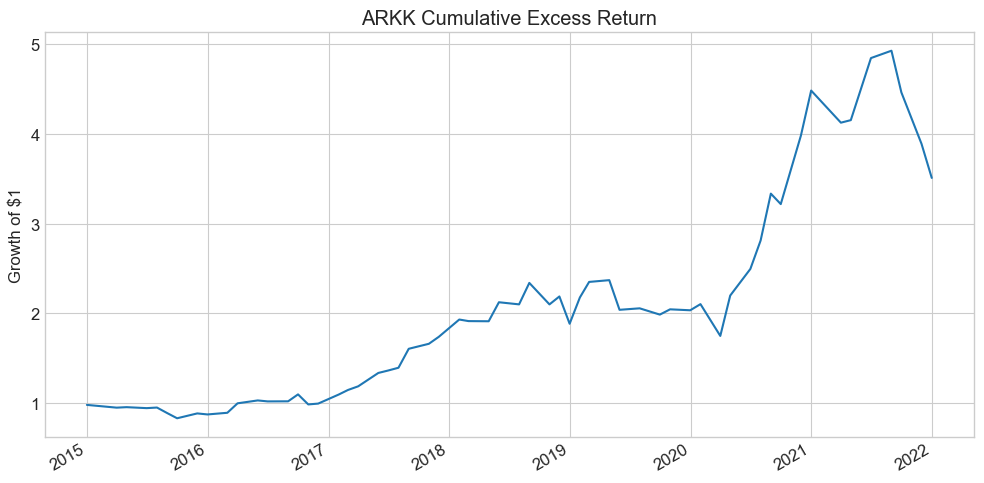

Annualized mean excess return: 644.7%


In [7]:
df = pd.read_pickle('https://raw.githubusercontent.com/amoreira2/Fin418/main/assets/data/df_WarrenBAndCathieW_monthly.pkl')
_temp = df.drop(['BRK'], axis=1).dropna()

Factors = _temp.drop(['RF', 'ARKK'], axis=1)
ArK = _temp.ARKK - _temp.RF

(ArK + 1).cumprod().plot(title='ARKK Cumulative Excess Return', figsize=(10, 5))
plt.ylabel('Growth of $1')
plt.tight_layout()
plt.show()

print(f"Annualized mean excess return: {ArK.mean()*252:.1%}")

The Fama-French factors capture different investment styles:

| Factor | Strategy |
|--------|----------|
| **HML** | Buy high book-to-market (value), sell low (growth) |
| **SMB** | Buy small caps, sell large caps |
| **RMW** | Buy high profitability, sell low profitability |
| **CMA** | Buy low investment (conservative), sell high investment (aggressive) |
| **MOM** | Buy recent winners, sell recent losers |

For now, think of these as important trading strategies that practitioners know well. We'll discuss their economics in detail later.

In [8]:
# Multi-factor regression (annualized)
x = sm.add_constant(Factors * 252)
y = ArK * 252
results = sm.OLS(y, x).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.838
Model:                            OLS   Adj. R-squared:                  0.820
Method:                 Least Squares   F-statistic:                     44.90
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           7.32e-19
Time:                        15:15:29   Log-Likelihood:                -215.14
No. Observations:                  59   AIC:                             444.3
Df Residuals:                      52   BIC:                             458.8
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.7109      1.396      1.225      0.226      -1.091       4.513
Mkt-RF         1.5432      0.155      9.931      0.000       1.231       1.855
SMB            0.3449      0.249      1.387      0.171      -0.154       0.844
HML           -0.9504      0.204     -4.667      0.000      -1.359      -0.542
RMW           -0.8065      0.306     -2.636      0.011      -1.420      -0.193
CMA           -0.5312      0.379     -1.403      0.167      -1.291       0.229
Mom           -0.2441      0.176     -1.390      0.170      -0.596       0.108
==============================================================================
Omnibus:                       11.073   Durbin-Watson:                   1.753
Prob(Omnibus):                  0.004   Jarque-Bera (JB):               11.234
Skew:                           0.896   Prob(JB):                      0.00364
Kurtosis:                       4.165   Cond. No.                         16.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

> **🤔 Think and Code:**
>
> 1. How much of ARKK's return behavior can we explain with factors?
> 2. What kind of stocks does Cathie Wood like? (Look at the factor loadings)
> 3. How much portfolio variance comes from market exposure alone vs. being anti-value?
> 4. What would the volatility of the hedged (residual) portfolio be?
> 5. When did she earn her alpha? Is it smooth or concentrated in a few periods?

---

## Warren Buffett: Does He Beat the Market? <a id="warren-buffett"></a>

![Warren Buffett](https://github.com/amoreira2/UG54/blob/main/assets/plots/WB_image.jpg?raw=1)

Warren Buffett is the chairman and CEO of Berkshire Hathaway. His top holdings include Apple, Bank of America, Chevron, Coca-Cola, and American Express. He's known for a long-term, value-oriented approach — large, blue-chip companies with strong balance sheets and attractive valuations.

Let's apply the same factor regression framework to Berkshire Hathaway.

In [9]:
# Single-factor CAPM regression
BrK = df.BRK - df.RF
x = sm.add_constant(df['Mkt-RF'])
results = sm.OLS(BrK, x).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.223
Model:                            OLS   Adj. R-squared:                  0.220
Method:                 Least Squares   F-statistic:                     79.32
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           7.17e-17
Time:                        15:15:29   Log-Likelihood:                 442.23
No. Observations:                 279   AIC:                            -880.5
Df Residuals:                     277   BIC:                            -873.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0054      0.003      1.797      0.073      -0.001       0.011
Mkt-RF         0.5919      0.066      8.906      0.000       0.461       0.723
==============================================================================
Omnibus:                       51.668   Durbin-Watson:                   1.989
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              198.575
Skew:                           0.710   Prob(JB):                     7.59e-44
Kurtosis:                       6.882   Cond. No.                         22.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

- What do we learn? Is the alpha large economically? Statistically?
- How should we think about this alpha?

Now let's use the full multi-factor model:

In [10]:
# Multi-factor regression: FF5 + Momentum
Factors = df.drop(['BRK', 'RF', 'ARKK'], axis=1)
x = sm.add_constant(Factors)
y = df.BRK - df.RF
results = sm.OLS(y, x).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.405
Model:                            OLS   Adj. R-squared:                  0.392
Method:                 Least Squares   F-statistic:                     30.81
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           3.71e-28
Time:                        15:15:29   Log-Likelihood:                 479.45
No. Observations:                 279   AIC:                            -944.9
Df Residuals:                     272   BIC:                            -919.5
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0037      0.003      1.307      0.192      -0.002       0.009
Mkt-RF         0.6938      0.070      9.907      0.000       0.556       0.832
SMB           -0.3087      0.097     -3.193      0.002      -0.499      -0.118
HML            0.5732      0.130      4.398      0.000       0.317       0.830
RMW            0.3486      0.123      2.827      0.005       0.106       0.591
CMA           -0.4156      0.191     -2.171      0.031      -0.792      -0.039
Mom           -0.0152      0.059     -0.255      0.799      -0.132       0.102
==============================================================================
Omnibus:                       34.823   Durbin-Watson:                   1.948
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               71.498
Skew:                           0.647   Prob(JB):                     2.98e-16
Kurtosis:                       5.116   Cond. No.                         82.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

> **🤔 Think and Code:**
>
> 1. Did adding factors change the alpha? By how much?
> 2. What kind of stocks does Warren like? (Look at the factor loadings)
> 3. What does this tell us about his investment *style* vs. his stock-picking *skill*?
> 4. How does his profile compare to Cathie Wood's?

---

## Bottom-Up vs Top-Down Decomposition <a id="bottom-up-top-down"></a>

So far we estimated fund factor exposures by looking at how the fund's returns **co-move** with factors (top-down). An alternative: look *through* the fund at individual holdings (bottom-up).

If a portfolio with weights $X$ earns excess returns $r = X'R$, and each asset satisfies:

$$R = A + B \cdot F + U$$

then the portfolio satisfies:

$$r = X'A + X'B \cdot F + X'U$$

So the portfolio's exposure to factor $j$ is the **dollar-weighted average** of the asset betas:

$$\beta_{p,j} = \sum_i x_i \, \beta_{i,j}$$

> **💡 Key Insight:**
>
> For high-turnover portfolios, the bottom-up approach tracks exposures much better
> because it refreshes at the holding level. For stable portfolios, top-down regressions
> are simpler and avoid the noise of estimating individual-stock betas.

### Sample Portfolio: Tech → Retail Rotation

In [11]:
import pandas as pd

date1, date2, date3 = '2014-12-31', '2015-12-31', '2016-12-31'

# Portfolio 1: Tech (2014-2015)
portfolio_data1 = {
    'date': [date1]*5,
    'ticker': ['AAPL', 'GOOGL', 'MSFT', 'NVDA', 'AMZN'],
    'weight': [0.2, 0.2, 0.2, 0.2, 0.2]
}
# Portfolio 2: Retail (2015-2016)
portfolio_data2 = {
    'date': [date2]*4,
    'ticker': ['COST', 'WMT', 'TGT', 'KR'],
    'weight': [0.25, 0.25, 0.25, 0.25]
}

portfolio_df1 = pd.DataFrame(portfolio_data1)
portfolio_df2 = pd.DataFrame(portfolio_data2)

# Expand to daily holdings
date_range1 = pd.date_range(start=date1, end=date2, freq='B')
date_range2 = pd.date_range(start=date2, end=date3, freq='B')

monthly_portfolio1 = pd.DataFrame(
    [(d, t, w) for d in date_range1 for t, w in zip(portfolio_df1['ticker'], portfolio_df1['weight'])],
    columns=['date', 'ticker', 'weight'])
monthly_portfolio2 = pd.DataFrame(
    [(d, t, w) for d in date_range2 for t, w in zip(portfolio_df2['ticker'], portfolio_df2['weight'])],
    columns=['date', 'ticker', 'weight'])

final_portfolio_df = pd.concat([monthly_portfolio1, monthly_portfolio2], ignore_index=True)
final_portfolio_df

,date,ticker,weight
0,2014-12-31,AAPL,0.20
1,2014-12-31,GOOGL,0.20
2,2014-12-31,MSFT,0.20
3,2014-12-31,NVDA,0.20
4,2014-12-31,AMZN,0.20
...,...,...,...
2353,2016-12-29,KR,0.25
2354,2016-12-30,COST,0.25
2355,2016-12-30,WMT,0.25
2356,2016-12-30,TGT,0.25


In [12]:
# Get stock returns and factors
tickers = final_portfolio_df.ticker.unique().tolist()
df_stocks = get_daily_wrds_multiple_ticker(tickers, conn)
df_factor = get_factors('FF6', 'daily').dropna()
df_stocks = df_stocks.subtract(df_factor['RF'], axis=0)

Found PERMNOs: [10107, 14593, 16678, 49154, 55976, 84788, 86580, 87055, 90319]


In [13]:
# Merge portfolio weights with stock returns
df_merged = df_stocks.stack()
df_merged.name = 'eret'
df_merged = final_portfolio_df.merge(df_merged, left_on=['date', 'ticker'], right_index=True, how='left')
df_merged.head()

,date,ticker,weight,eret
0,2014-12-31,AAPL,0.2,-0.019019
1,2014-12-31,GOOGL,0.2,-0.008631
2,2014-12-31,MSFT,0.2,-0.012123
3,2014-12-31,NVDA,0.2,-0.01571
4,2014-12-31,AMZN,0.2,0.000161


### Top-Down Approach

Construct the portfolio return first, then run the multi-factor regression:

In [14]:
fund_return = df_merged.groupby('date').apply(lambda x: (x['eret'] * x['weight']).sum())
df_factor, fund_return = df_factor.align(fund_return, join='inner', axis=0)

In [15]:
# Full-sample regression
y = fund_return.dropna()
X = sm.add_constant(df_factor.drop(columns=['RF']).loc[y.index])
model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.539
Model:                            OLS   Adj. R-squared:                  0.533
Method:                 Least Squares   F-statistic:                     97.05
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           1.66e-80
Time:                        15:15:34   Log-Likelihood:                 1715.3
No. Observations:                 505   AIC:                            -3417.
Df Residuals:                     498   BIC:                            -3387.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0005      0.000      1.408      0.160      -0.000       0.001
Mkt-RF         0.9482      0.044     21.464      0.000       0.861       1.035
SMB           -0.1250      0.080     -1.573      0.116      -0.281       0.031
HML            0.0096      0.101      0.096      0.924      -0.188       0.207
RMW            0.7211      0.117      6.160      0.000       0.491       0.951
CMA           -0.5525      0.147     -3.770      0.000      -0.840      -0.265
MOM            0.1502      0.050      3.008      0.003       0.052       0.248
==============================================================================
Omnibus:                       94.691   Durbin-Watson:                   1.942
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              342.514
Skew:                           0.819   Prob(JB):                     4.21e-75
Kurtosis:                       6.687   Cond. No.                         461.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Now suppose you know the portfolio changed at end-2015. You can break the regression into two windows — but what do you lose in precision?

In [16]:
# Period 1: tech portfolio (2014-2015)
y1 = fund_return[:'2015-12-31'].dropna()
X1 = sm.add_constant(df_factor.drop(columns=['RF']).loc[y1.index])
model1 = sm.OLS(y1, X1).fit()
display(model1.summary())

# Period 2: retail portfolio (2016)
y2 = fund_return['2015-12-31':].dropna()
X2 = sm.add_constant(df_factor.drop(columns=['RF']).loc[y2.index])
model2 = sm.OLS(y2, X2).fit()
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.771
Model:                            OLS   Adj. R-squared:                  0.765
Method:                 Least Squares   F-statistic:                     137.9
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           9.55e-76
Time:                        15:15:34   Log-Likelihood:                 907.78
No. Observations:                 253   AIC:                            -1802.
Df Residuals:                     246   BIC:                            -1777.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0009      0.000      1.995      0.047    1.08e-05       0.002
Mkt-RF         1.0123      0.048     21.135      0.000       0.918       1.107
SMB           -0.2453      0.101     -2.439      0.015      -0.443      -0.047
HML            0.2501      0.135      1.859      0.064      -0.015       0.515
RMW            0.7186      0.170      4.231      0.000       0.384       1.053
CMA           -2.0396      0.214     -9.511      0.000      -2.462      -1.617
MOM           -0.0418      0.063     -0.659      0.511      -0.167       0.083
==============================================================================
Omnibus:                       86.620   Durbin-Watson:                   1.814
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              377.103
Skew:                           1.336   Prob(JB):                     1.30e-82
Kurtosis:                       8.351   Cond. No.                         568.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.335
Model:                            OLS   Adj. R-squared:                  0.319
Method:                 Least Squares   F-statistic:                     20.63
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           1.51e-19
Time:                        15:15:34   Log-Likelihood:                 870.23
No. Observations:                 253   AIC:                            -1726.
Df Residuals:                     246   BIC:                            -1702.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0004      0.001     -0.705      0.481      -0.001       0.001
Mkt-RF         0.7193      0.070     10.242      0.000       0.581       0.858
SMB            0.1228      0.108      1.135      0.258      -0.090       0.336
HML           -0.0331      0.125     -0.265      0.791      -0.279       0.213
RMW            0.7591      0.144      5.289      0.000       0.476       1.042
CMA            0.0837      0.175      0.479      0.633      -0.261       0.428
MOM            0.1594      0.069      2.314      0.022       0.024       0.295
==============================================================================
Omnibus:                        8.063   Durbin-Watson:                   2.104
Prob(Omnibus):                  0.018   Jarque-Bera (JB):               13.473
Skew:                          -0.109   Prob(JB):                      0.00119
Kurtosis:                       4.109   Cond. No.                         408.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Strategy Abnormal Returns

Armed with betas, we construct abnormal returns by stripping out factor-explained performance:

$$\text{Abnormal}_t = R_t - \sum_j \beta_j \, f_t^j$$

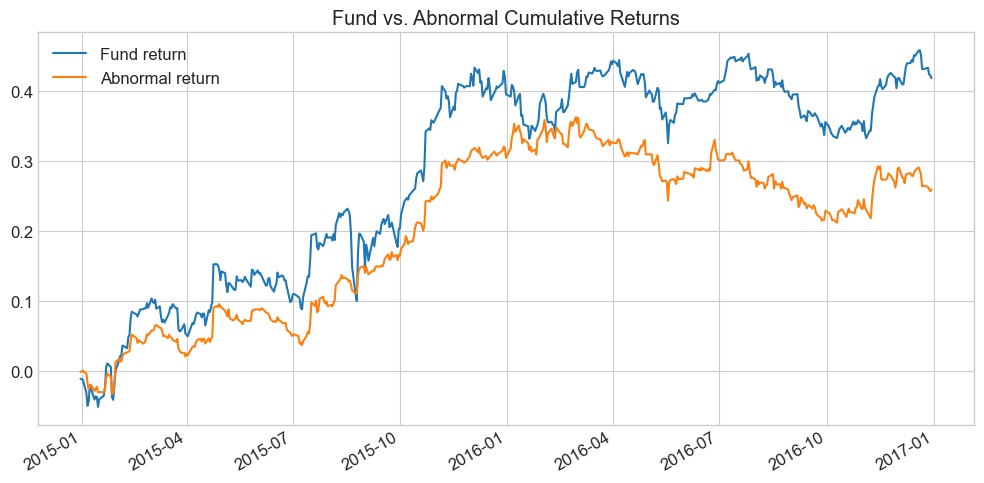

In [17]:
abnormal_return = fund_return - df_factor.drop(columns=['RF']) @ model.params[1:]

fig, ax = plt.subplots(figsize=(10, 5))
fund_return.cumsum().plot(ax=ax, label='Fund return')
abnormal_return.cumsum().plot(ax=ax, label='Abnormal return')
ax.set_title('Fund vs. Abnormal Cumulative Returns')
ax.legend()
plt.tight_layout()
plt.show()

> **🤔 Think and Code:**
>
> 1. How can you compute abnormal returns more easily from regression outputs?
>    *Hint:* which regression statistic equals the average abnormal return?
> 2. What does the pattern of abnormal returns tell you about the fund's skill?

### Bottom-Up Approach

Now we estimate factor betas for each *stock*, then use portfolio weights to compute fund exposures date-by-date:

In [18]:
# Estimate factor betas for each stock
df_factor, df_stocks = df_factor.align(df_stocks, join='inner', axis=0)
Xf = df_factor.drop(columns=['RF'])

B = pd.DataFrame([], index=tickers, columns=Xf.columns)
for ticker in df_stocks.columns:
    y = df_stocks[ticker].dropna()
    X = sm.add_constant(Xf.loc[y.index])
    model = sm.OLS(y, X).fit()
    B.loc[ticker, :] = model.params[1:]

B

,Mkt-RF,SMB,HML,RMW,CMA,MOM
AAPL,1.023921,-0.099693,0.098624,0.821751,-1.516863,-0.029002
GOOGL,0.944916,-0.445416,-0.053068,-0.052756,-1.334679,0.161329
MSFT,1.227477,-0.309171,0.164822,0.690796,-1.156395,0.097671
NVDA,1.269493,0.688041,-0.293219,0.298152,-0.264944,0.168911
AMZN,0.986571,-0.399886,0.24572,-0.143481,-2.160607,0.257187
COST,0.788138,-0.030709,0.042829,0.740032,-0.038182,0.210871
WMT,0.777156,-0.142485,-0.255371,0.858924,0.442454,0.105975
TGT,0.862613,0.297714,-0.103554,1.250017,0.49437,0.102883
KR,0.734953,0.055092,0.023944,0.298958,-0.165853,0.313963


With individual betas in hand, we can compute **fund-level exposures date by date** using current portfolio weights. This matters a lot for funds that trade frequently:

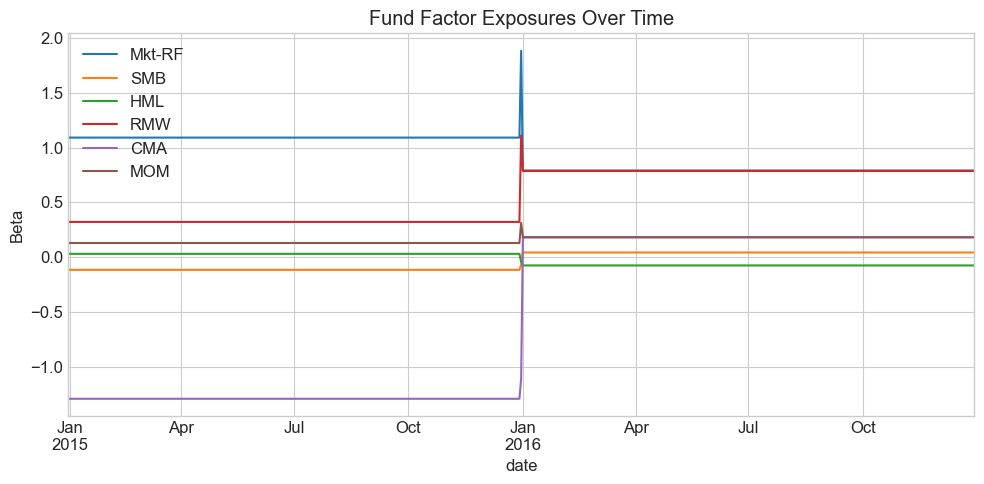

,Mkt-RF,SMB,HML,RMW,CMA,MOM
date,,,,,,
2014-12-31,1.090475,-0.113225,0.032576,0.322892,-1.286698,0.131219
2015-01-01,1.090475,-0.113225,0.032576,0.322892,-1.286698,0.131219
2015-01-02,1.090475,-0.113225,0.032576,0.322892,-1.286698,0.131219
2015-01-05,1.090475,-0.113225,0.032576,0.322892,-1.286698,0.131219
2015-01-06,1.090475,-0.113225,0.032576,0.322892,-1.286698,0.131219
...,...,...,...,...,...,...
2016-12-26,0.790715,0.044903,-0.073038,0.786983,0.183197,0.183423
2016-12-27,0.790715,0.044903,-0.073038,0.786983,0.183197,0.183423
2016-12-28,0.790715,0.044903,-0.073038,0.786983,0.183197,0.183423


In [19]:
_temp = final_portfolio_df.merge(B, left_on='ticker', right_index=True, how='left')
Fund_B = _temp.groupby('date').apply(
    lambda x: pd.Series((x[Xf.columns].values * x['weight'].values.reshape(-1, 1)).sum(axis=0), index=Xf.columns))

Fund_B.plot(title='Fund Factor Exposures Over Time', figsize=(10, 5))
plt.ylabel('Beta')
plt.tight_layout()
plt.show()

Fund_B

> **📌 Remember:**
>
> There is no reason to believe asset betas are stable over time. The general recipe:
> - **Daily data**: 1–2 year estimation windows
> - **Monthly data**: ~5 year windows
>
> Long samples give precision if betas are constant; short samples capture time-variation.

---

## The Cross-Sectional Approach <a id="cross-sectional"></a>

In the time-series approach, we start from *factors* and estimate betas. Now we **flip this**: start from *characteristics* (which are the betas) and estimate the returns associated with each characteristic.

### Time-Series vs. Cross-Sectional

| | Time-Series | Cross-Sectional |
|---|---|---|
| **Starts from** | Factor returns | Asset characteristics |
| **Estimates** | Betas (loadings) | Factor premia (returns to characteristics) |
| **Requires** | Traded factors | Large cross-section of stocks |
| **Best for** | Small number of well-defined factors | Many characteristics simultaneously |

### The Recipe

1. Get excess returns $R$ for all stocks at date $t$
2. Get characteristics $X$ for those stocks as of date $t-1$ (to avoid look-ahead bias!)
3. Normalize characteristics cross-sectionally (z-scores)
4. Run the cross-sectional regression: $R = X \beta + \epsilon$

From OLS: $\beta = (X'X)^{-1}X'R$

> **💡 Key Insight:**
>
> The $\beta$ coefficients are **excess returns themselves** — they are returns on
> "pure play" portfolios designed to have a loading of 1 on one characteristic
> and zero on all others. The weights $(X'X)^{-1}X'$ are the portfolio weights.

In [20]:
# Load characteristics data
url = "https://github.com/amoreira2/Fin418/blob/main/assets/data/characteristics_raw.pkl?raw=true"
df_X = pd.read_pickle(url)
# Shift dates to end-of-month basis
df_X.set_index(['date', 'permno'], inplace=True)
df_X.head()

re      rf     rme       size     value      prof  \
date       permno                                                            
2006-01-31 10085   0.025224  0.0035  0.0304  14.132980 -0.775040 -2.223152   
           10104   0.025984  0.0035  0.0304  18.034086 -2.186115 -0.458025   
           10107   0.072982  0.0035  0.0304  19.399144 -1.357207 -1.094087   
           10137   0.095710  0.0035  0.0304  15.226304 -0.256102 -2.418484   
           10138   0.057586  0.0035  0.0304  15.913684 -1.553967 -1.227315   

                   fscore  debtiss  repurch     nissa  ...    momrev  \
date       permno                                      ...             
2006-01-31 10085        7        0        1  0.691947  ...  0.527791   
           10104        6        1        1  0.690818  ...  0.111133   
           10107        4        1        1  0.686126  ...  0.133546   
           10137        7        0        0  0.824237  ...  0.295023   
           10138        7        1        1  0.704786  ...  0.213203   

                     valuem     nissm     strev      ivol   betaarb   indrrev  \
date       permno                                                               
2006-01-31 10085  -0.711504  0.697500 -0.003088  0.003396  1.030378 -0.003491   
           10104  -1.633254  0.687115 -0.030952  0.012757  1.473739 -0.005108   
           10107  -1.725634  0.667695 -0.055275  0.006959  1.166726 -0.029431   
           10137  -0.743060  0.782290  0.137262  0.012228  0.834982  0.124839   
           10138  -1.661273  0.701101  0.005004  0.006970  1.263471 -0.001327   

                      price       age     shvol  
date       permno                                
2006-01-31 10085   3.569814  5.480639  0.723779  
           10104   2.502255  5.480639  1.007820  
           10107   3.263849  5.480639  0.856907  
           10137   3.454738  6.349139  0.952114  
           10138   4.277083  5.476464  0.605547  

[5 rows x 32 columns]

In [21]:
# Standardize characteristics cross-sectionally (z-scores by date)
X_std = (df_X.drop(columns=['re', 'rf', 'rme'])
         .groupby('date')
         .transform(lambda x: (x - x.mean()) / x.std()))

In [22]:
# Run the cross-sectional regression for a single month
date = '2006-09'
X = X_std.loc[date]
R = df_X.loc[date, 're']

# Multiply by 100 for percentage returns
model = sm.OLS(100 * R, X).fit()
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                     re   R-squared (uncentered):                   0.158
Model:                            OLS   Adj. R-squared (uncentered):              0.131
Method:                 Least Squares   F-statistic:                              6.017
Date:                Mon, 13 Apr 2026   Prob (F-statistic):                    1.81e-20
Time:                        15:15:36   Log-Likelihood:                         -3128.4
No. Observations:                 962   AIC:                                      6315.
Df Residuals:                     933   BIC:                                      6456.
Df Model:                          29                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

**What does this mean?**

- The size coefficient means a portfolio with one standard deviation of size exposure (and zero of everything else) earned that return in this month
- Because we normalized, "one unit" means one cross-sectional standard deviation above the mean

What are the portfolios behind these coefficients?

In [23]:
# Portfolio weights for each characteristic "pure play"
# Rows = characteristics, columns = stocks
Characteristic_portfolio_weights = np.linalg.inv(X.T @ X) @ X.T
Characteristic_portfolio_weights.index = X.columns
Characteristic_portfolio_weights

date      2006-09-30                                                    \
permno         10104     10107     10137     10138     10143     10145   
size        0.002726  0.004360 -0.000686 -0.000294 -0.001032  0.001538   
value      -0.002632  0.006965  0.000676  0.000402  0.001094  0.000918   
prof       -0.004929 -0.005258  0.002034  0.002285 -0.008617  0.002159   
fscore     -0.000836  0.000893 -0.000555 -0.000177  0.002782  0.001506   
debtiss    -0.001236  0.001006 -0.000597  0.000775 -0.000740  0.002011   
repurch     0.000264 -0.001071  0.001303  0.000584  0.002529  0.000491   
nissa      -0.001617  0.000601 -0.000104 -0.000428 -0.002482 -0.000482   
growth      0.002627 -0.002042 -0.001180  0.000641  0.006734  0.001257   
aturnover   0.004871  0.004464 -0.003664 -0.007132  0.007850 -0.000981   
gmargins    0.003855  0.004819 -0.002342 -0.003515  0.005676 -0.002311   
ep          0.000271 -0.000069 -0.000293  0.000143 -0.000826 -0.000250   
sgrowth    -0.000287  0.000121  0.000095 -0.000050  0.001933  0.000055   
lev        -0.001423 -0.001301 -0.001663 -0.005339 -0.005967  0.000626   
roaa        0.001069  0.001812 -0.000686  0.002124 -0.008606 -0.001630   
roea       -0.000707 -0.000298  0.000059 -0.000892  0.002531  0.000550   
sp          0.000065  0.000296 -0.000223  0.002129 -0.000102 -0.000631   
mom         0.003275 -0.001444  0.000414  0.000814  0.004850  0.000500   
indmom     -0.001036 -0.000790  0.001130 -0.000069 -0.000559  0.000744   
mom12      -0.000448 -0.000538  0.000771  0.000531 -0.003858 -0.001458   
momrev     -0.000637 -0.000340  0.002424 -0.000383 -0.004906 -0.000384   
valuem      0.002454 -0.006450 -0.000259  0.000282 -0.000720 -0.001481   
nissm       0.001268 -0.001002  0.000261  0.000340  0.002121  0.000014   
strev       0.001438  0.000856  0.001983 -0.003842 -0.001651 -0.005159   
ivol       -0.000693 -0.000813 -0.000575 -0.000243 -0.000003 -0.000482   
betaarb     0.001033 -0.001787 -0.000101  0.002654  0.001072  0.002249   
indrrev    -0.000593 -0.000945 -0.001676  0.004517  0.003180  0.004748   
price      -0.002615 -0.001900 -0.000078  0.000075  0.001128 -0.000128   
age         0.000211 -0.000759  0.001319  0.000274  0.002850  0.000730   
shvol      -0.000060  0.001666  0.000600 -0.002817  0.002260 -0.001090   

date                                               ...                      \
permno        10147     10182     10225     10299  ...     89702     89753   
size       0.001587 -0.000573  0.000838 -0.000320  ... -0.000651 -0.000082   
value      0.000914  0.001651  0.000402  0.000781  ...  0.002959 -0.001872   
prof      -0.000689 -0.001997  0.003331 -0.006068  ... -0.019083  0.002454   
fscore     0.002053 -0.000181 -0.001518  0.001342  ...  0.000608 -0.000435   
debtiss   -0.001833  0.001377 -0.000026 -0.000127  ...  0.000919  0.000659   
repurch    0.000340 -0.001383 -0.001643 -0.000055  ... -0.000987 -0.001089   
nissa     -0.000480  0.000256 -0.001693  0.000070  ...  0.001202  0.000048   
growth     0.000534  0.000382  0.002447 -0.000216  ... -0.000920 -0.000798   
aturnover  0.000484 -0.008215 -0.003439  0.002336  ...  0.023270 -0.004813   
gmargins   0.000605  0.001060 -0.001483  0.003727  ...  0.011010 -0.002337   
ep        -0.000066  0.006725  0.000147  0.000138  ... -0.000719  0.000504   
sgrowth    0.000081 -0.000231 -0.000377  0.000371  ... -0.000251 -0.000266   
lev       -0.000846 -0.012928 -0.000303 -0.003485  ...  0.002164 -0.002672   
roaa      -0.000170 -0.002489 -0.001095  0.002394  ...  0.000023  0.000402   
roea       0.000388  0.000520  0.000250 -0.000938  ...  0.000191 -0.000201   
sp        -0.000166  0.017161 -0.000159  0.001461  ... -0.002150  0.000303   
mom       -0.000680 -0.001967  0.001638  0.001538  ... -0.000963  0.006294   
indmom     0.001156 -0.000728 -0.003179 -0.000662  ... -0.000162  0.000246   
mom12     -0.000226  0.000581 -0.001932 -0.001952  ... -0.000535 -0.002585   
momrev    -0.000023 -0.001467  0.000014 -0.000539  ...  0.000848 -0

### Applications

With these cross-sectional regressions we can:

1. **Compute characteristic-adjusted returns** for any portfolio — just subtract the returns implied by its characteristics
2. **Construct factor return time-series** — splice together the regression coefficients across dates to get $[\beta_t, \beta_{t+1}, \ldots]$

### Constructing Characteristic-Adjusted Returns

We can get a portfolio's characteristics and compute the returns *implied* by those characteristics. Subtracting these from actual returns gives the **characteristic-adjusted return** — the equivalent of "hedging" but using characteristics instead of time-series betas.

In [24]:
# Step 1: Define two sample portfolios (tech and retail)
portfolio_data1 = {'port': [1]*5,
    'ticker': ['AAPL', 'GOOG', 'MSFT', 'NVDA', 'AMZN'],
    'weight': [0.2, 0.2, 0.2, 0.2, 0.2]}

portfolio_data2 = {'port': [2]*4,
    'ticker': ['COST', 'WMT', 'TGT', 'KR'],
    'weight': [0.25, 0.25, 0.25, 0.25]}

portfolio_df = pd.concat([pd.DataFrame(portfolio_data1), pd.DataFrame(portfolio_data2)], ignore_index=True)
print(portfolio_df)

   port ticker  weight
0     1   AAPL    0.20
1     1   GOOG    0.20
2     1   MSFT    0.20
3     1   NVDA    0.20
4     1   AMZN    0.20
5     2   COST    0.25
6     2    WMT    0.25
7     2    TGT    0.25
8     2     KR    0.25


In [25]:
# Step 2: Get PERMNOs for ticker matching (our data uses PERMNOs, not tickers)
permno = get_permnos(portfolio_df.ticker.unique(), conn)
permno['namedt'] = pd.to_datetime(permno['namedt'])
permno['nameenddt'] = pd.to_datetime(permno['nameenddt'])

date = '2008-03'
d = pd.to_datetime(date)
# Get PERMNOs valid at this date (they can change over time!)
permno_d = permno[(permno['nameenddt'] >= d) & (permno['namedt'] <= d)]
portfolio_df = portfolio_df.merge(permno_d[['permno', 'ticker']], on='ticker', how='left')
portfolio_df

,port,ticker,weight,permno
0,1,AAPL,0.20,14593
1,1,GOOG,0.20,90319
2,1,MSFT,0.20,10107
3,1,NVDA,0.20,86580
4,1,AMZN,0.20,84788
5,2,COST,0.25,87055
6,2,WMT,0.25,55976
7,2,TGT,0.25,49154
8,2,KR,0.25,16678


In [26]:
# Step 3: Merge portfolio with characteristics data
# Here we do it for one date; for multiple dates, add 'date' as a second identifier
X = X_std.loc[date].reset_index()
port_stocks_X = portfolio_df.merge(X, left_on='permno', right_on='permno', how='left')
port_stocks_X

,port,ticker,weight,permno,date,size,value,prof,fscore,debtiss,...,momrev,valuem,nissm,strev,ivol,betaarb,indrrev,price,age,shvol
0,1,AAPL,0.20,14593,2008-03-31,2.410205,-1.315480,0.455224,-0.091077,1.303219,...,0.575718,-1.421058,0.147848,-0.580727,0.330686,0.752957,-0.868990,1.888114,0.398208,2.904418
1,1,GOOG,0.20,90319,2008-03-31,2.528013,-1.118659,0.564933,-0.091077,1.303219,...,0.755154,-1.005315,0.229125,-1.402481,0.158169,-0.694430,-1.224557,3.959159,-2.339689,1.693268
2,1,MSFT,0.20,10107,2008-03-31,3.257090,-1.363239,0.985259,0.755457,1.303219,...,0.726842,-1.531135,-0.438239,-1.377024,-0.637930,-0.456596,-1.195484,-0.492776,0.105671,-0.399737
3,1,NVDA,0.20,86580,2008-03-31,0.680226,-1.634531,0.817117,0.755457,1.303219,...,1.172971,-0.842731,0.223491,-1.079041,1.603828,2.812533,-1.183732,-0.867861,-1.084778,1.545659
4,1,AMZN,0.20,84788,2008-03-31,1.240524,-3.728875,1.118980,-0.091077,1.303219,...,1.249185,-3.528315,0.034269,-1.451173,0.544068,1.264655,-1.341326,0.854323,-0.858657,1.347997
5,2,COST,0.25,87055,2008-03-31,1.154301,0.138992,0.785716,-0.091077,-0.766462,...,-0.499439,-0.268807,-0.301382,-0.674229,-0.579135,-0.414050,-0.454017,0.791327,0.126212,0.223698
6,2,WMT,0.25,55976,2008-03-31,2.960595,-0.322603,1.029022,-0.937610,-0.766462,...,-0.424544,-0.260600,-0.348921,-0.082608,-1.065065,-0.802397,0.221643,0.444707,0.753804,-1.140483
7,2,TGT,0.25,49154,2008-03-31,1.815796,-0.209013,0.909948,1.601991,-0.766462,...,0.974779,-0.055104,-0.423087,-0.319158,0.450388,0.077535,-0.048508,0.536987,0.871398,0.443988
8,2,KR,0.25,16678,2008-03-31,0.934108,-0.149013,1.326149,0.755457,-0.766462,...,-0.172023,-0.295956,-0.406029,-0.282320,-0.487468,-0.728124,-0.006437,-0.671970,1.220560,-0.344465


In [27]:
# Step 4: Compute portfolio-level characteristics (weighted average)
X_names = X.drop(columns=['permno', 'date']).columns
port_X = port_stocks_X.groupby('port').apply(lambda x: x['weight'] @ x[X_names])
port_X

weight,size,value,prof,fscore,debtiss,repurch,nissa,growth,aturnover,gmargins,...,momrev,valuem,nissm,strev,ivol,betaarb,indrrev,price,age,shvol
port,,,,,,,,,,,,,,,,,,,,,
1,2.023212,-1.832157,0.788303,0.247537,1.303219,0.202595,-0.021355,0.558931,0.525197,0.320116,...,0.895974,-1.665711,0.039299,-1.178089,0.399764,0.735824,-1.162818,1.068192,-0.755849,1.418321
2,1.716200,-0.135409,1.012709,0.332190,-0.766462,0.642131,-0.272052,-0.261772,1.427599,-0.806162,...,-0.030307,-0.220117,-0.369855,-0.339578,-0.420320,-0.466759,-0.071830,0.275263,0.742994,-0.204316


In [28]:
# Step 5: Estimate returns associated with each characteristic (full universe)
X = X_std.loc[date]
R = df_X.loc[date, 're']
model = sm.OLS(R, X).fit()
R_X = model.params
R_X

size        -0.008685
value        0.010048
prof         0.014476
fscore      -0.000212
debtiss     -0.009435
repurch      0.008764
nissa        0.007878
growth       0.001369
aturnover   -0.026765
gmargins    -0.011491
ep          -0.001229
sgrowth     -0.007586
lev         -0.026462
roaa        -0.008852
roea         0.006974
sp           0.007249
mom          0.005713
indmom      -0.008373
mom12        0.003797
momrev       0.000066
valuem      -0.006634
nissm       -0.005530
strev        0.013887
ivol        -0.007777
betaarb      0.003666
indrrev     -0.011385
price       -0.003223
age          0.004363
shvol       -0.007341
dtype: float64

In [29]:
# Step 6: Characteristic-implied returns
# This is the equivalent of sum(beta_j * f_j), but using characteristics as "betas"
# and the cross-sectional regression coefficients as "factors"
port_characteristic_returns = port_X[X_names] @ R_X
print("Characteristic-implied returns:")
print(port_characteristic_returns)

Characteristic-implied returns:
port
1   -0.027497
2    0.006339
dtype: float64


In [30]:
# Step 7: Characteristic-adjusted returns = actual - implied
_temp = portfolio_df.merge(R.reset_index(), left_on='permno', right_on='permno')
R_port = _temp.groupby('port').apply(lambda x: x['weight'] @ x['re'])

print("Raw excess returns:")
print(R_port)
print("\nCharacteristic-implied returns:")
print(port_characteristic_returns)
print("\nCharacteristic-adjusted returns:")
print(R_port - port_characteristic_returns)

Raw excess returns:
port
1    0.029733
2    0.030074
dtype: float64

Characteristic-implied returns:
port
1   -0.027497
2    0.006339
dtype: float64

Characteristic-adjusted returns:
port
1    0.057230
2    0.023735
dtype: float64


### Why Practitioners Like This

- **No time-series betas needed** — avoids all the issues with sample length and beta instability
- **Characteristics can change freely** — we estimate date-by-date, so the model adapts instantly
- **Scales to many factors** — just add columns to the regression (sector, country, currency, etc.)

### What Are the Issues?

- **Ignores covariances** — characteristic-neutral ≠ factor-neutral. A stock classified as "retail" might co-move with tech
- **Loads on small stocks** — OLS treats all observations equally, and most stocks are tiny. Fixes: weighted least squares (by market cap), or restrict to the largest 20% of stocks

> **⚠️ Caution:**
>
> The characteristic and factor-based approaches are **complements, not substitutes**.
> Characteristics are observable and easy to work with, but factors capture the
> actual return co-movement structure. Use both.

---

## 📝 Exercises <a id="exercises"></a>

### Exercise 1: Factor Attribution

> **🔧 Exercise:**
>
> Pick a fund or ETF of your choice (e.g., QQQ, XLF, ARKW).
> 1. Download its daily returns from WRDS
> 2. Run a multi-factor regression (FF5 + Momentum)
> 3. Report: alpha, t-stat, $R^2$, and the dominant factor exposures
> 4. In 2-3 sentences: what is this fund actually giving you?

In [31]:
# Your code here

### Exercise 2: Bottom-Up vs Top-Down

> **🤔 Think and Code:**
>
> Using the Tech → Retail portfolio from above:
> 1. Compare the fund betas from the top-down regression (full sample) to the bottom-up approach
> 2. Where do the biggest discrepancies appear? Why?
> 3. Which approach would you trust more for a high-turnover hedge fund?

In [32]:
# Your code here

---

## 🧠 Key Takeaways <a id="key-takeaways"></a>

- **Multi-factor models are the industry workhorse.** They capture multiple rewarded risks simultaneously, delivering more realistic benchmarks and richer performance attribution.

- **Alpha is scarce; beta is plentiful.** Time-series regressions reveal that most "smart-beta" ETFs provide factor exposure, not outperformance — true skill shows up only in the intercept.

- **Bottom-up attribution excels for high-turnover managers.** Refreshing exposures at the holding level avoids the lag and instability that afflict purely return-based estimates.

- **Characteristic models broaden the toolkit but ignore covariances.** They neutralize portfolios on observed attributes quickly and at scale, yet leave hidden co-movement risks untouched — factor and characteristic views are complements, not substitutes.

---

---

## 📎 Solutions

### ETF Evaluation (Think and Code)

<details>
<summary>💡 Click to see answer</summary>

Alpha alone is insufficient. You also need to consider:

1. **t-statistic** — is the alpha statistically significant, or could it be zero?
2. **Idiosyncratic volatility** — higher ivol means more tracking error and noisier alpha estimates
3. **Sample size** — some ETFs are newer with less data; shorter samples produce less reliable estimates
4. **Factor loadings** — a fund with high MOM loading is delivering factor exposure you could get cheaply from an index. That is not skill.

The comparison is only fair if sample periods overlap. Different start dates mean different market conditions, which can bias the results.

</details>

### Cathie Wood Factor Profile (Think and Code)

<details>
<summary>💡 Click to see answer</summary>

ARKK typically has $R^2$ around 0.4–0.6 with the FF5+MOM model. The loadings reveal:

- **High market beta** (~1.3+) — aggressive, amplifies market moves
- **Strongly negative HML** — anti-value / growth tilt (buys expensive, innovative firms)
- **Positive SMB** — tilts toward smaller firms
- **Negative CMA** — likes firms investing heavily (high capex)

**Market exposure dominates variance**, but the anti-value tilt contributes significantly. You can compute this as $\beta_{HML}^2*\text{Var}(HML)$.

The residual volatility is the regression's $\sigma(\epsilon)$ — this is what you'd bear if you hedged all factor exposures.

Her alpha is likely **concentrated in 2020** (pandemic tech/innovation boom), not smoothly distributed. This raises questions about persistence.

</details>

### Buffett: Multi-Factor Analysis (Think and Code)

<details>
<summary>💡 Click to see answer</summary>

Adding factors typically **reduces** Buffett's alpha relative to CAPM, because some of his apparent "skill" is actually systematic factor exposure.

**Buffett's factor loadings:**
- **Positive HML** — value investor (buys cheap stocks)
- **Positive RMW** — quality preference (profitable firms)
- **Slightly negative CMA** — likes firms that invest
- **Low/negative MOM** — contrarian, patient

He is the **anti–Cathie Wood**: conservative, value-oriented, high-quality. After controlling for factors, his remaining alpha represents genuine stock-picking skill.

**Buffett = value + quality + patience; Wood = growth + innovation + momentum.**

</details>

### Abnormal Returns Shortcut (Think and Code)

<details>
<summary>💡 Click to see answer</summary>

The **residuals** from the regression ARE the abnormal returns:

```python
abnormal_returns = model.resid  # exactly R_t - Σβ_j f_t^j
```

The alpha (intercept) is simply the **average** of these residuals.

If abnormal returns are clustered in one period, the "skill" may be period-specific rather than persistent — a red flag for forward-looking investment decisions.

</details>

### Exercise 1: Factor Attribution

<details>
<summary>💡 Click to see answer</summary>

```python
# Example with QQQ
ticker = "QQQ"
df_etf = get_daily_wrds_multiple_ticker([ticker], conn)
df_fac = get_factors("FF6", "daily")
df_etf, df_fac = df_etf.align(df_fac, join="inner", axis=0)
df_etf = df_etf.subtract(df_fac["RF"], axis=0)

y = df_etf[ticker].dropna()
X = sm.add_constant(df_fac.drop(columns=["RF"]).loc[y.index])
model = sm.OLS(y, X).fit()
print(model.summary())
print(f"Alpha (annualized): {model.params['const']*252:.4f}")
print(f"t-stat: {model.tvalues['const']:.2f}")
print(f"R²: {model.rsquared:.3f}")
```



</details>

### Exercise 2: Bottom-Up vs Top-Down

<details>
<summary>💡 Click to see answer</summary>

The **top-down** regression averages over the entire sample, so it **mixes** the tech and retail periods — the estimated betas are a blend that doesn't accurately represent either regime.

The **bottom-up** approach correctly shows the sharp shift in exposures at the rebalancing date (end-2015). The biggest discrepancies will be in:
- **HML** — tech stocks are growth (negative HML), retail stocks are closer to value
- **SMB** — tech mega-caps vs. mid-cap retailers

For a **high-turnover hedge fund**, bottom-up is strictly better because top-down estimates lag behind actual exposure changes. The regression needs months of data to detect a shift that happened overnight.

</details>